In [13]:
import sys
import subprocess
colab = False 

if "google.colab" in sys.modules:
    # Use Colab/Jupyter magic for installation
    colab = True
    %pip install -q scikit-image

import skimage as ski
import numpy as np

if colab:
    img = ski.io.imread("https://raw.githubusercontent.com/LOMA-AImotion/pdl_ss26/main/imaging/robos.jpg")
else: 
    img = ski.io.imread("thi.JPG")

    
import matplotlib.pyplot as plt

def imshow_matplotlib(image, cmap=None, **kwargs):
    plt.figure()
    if image.ndim == 2: # Grayscale image has only width and height as dimensions
        plt.imshow(image, cmap=cmap or "gray", **kwargs)
    else:
        plt.imshow(image, **kwargs)
    plt.axis("off")
    plt.show()

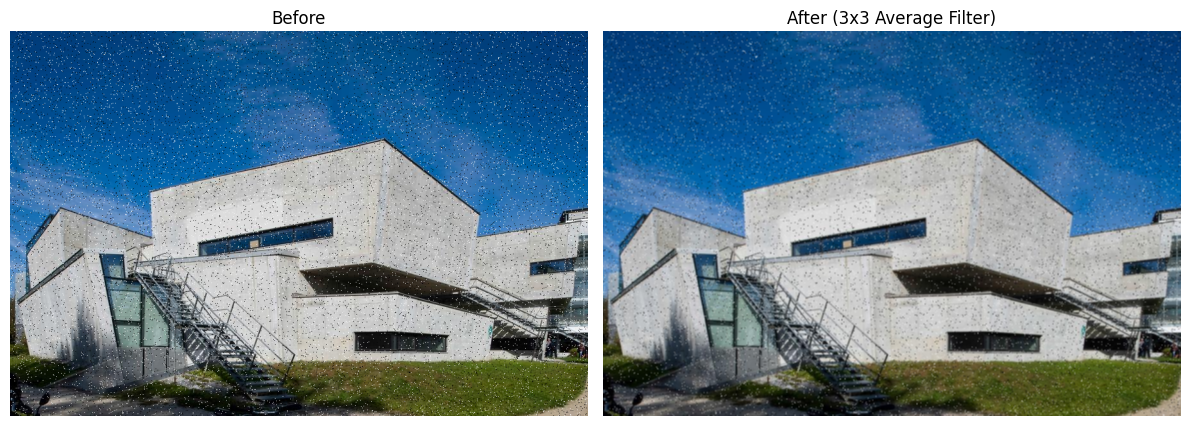

In [ ]:
# Add salt-and-pepper noise to the input image
rng = np.random.default_rng(42)
salt_prob = 0.02
pepper_prob = 0.02

img = img.copy()
h, w = img.shape[:2]

n_salt = int(salt_prob * h * w)
n_pepper = int(pepper_prob * h * w)

ys = rng.integers(0, h, n_salt)
xs = rng.integers(0, w, n_salt)
yp = rng.integers(0, h, n_pepper)
xp = rng.integers(0, w, n_pepper)

if img.ndim == 2:
    img[ys, xs] = 255  # salt (white)
    img[yp, xp] = 0    # pepper (black)
else:
    img[ys, xs, :] = 255
    img[yp, xp, :] = 0

# 3x3 average filter (manual, no extra imports)
img_f = img.astype(np.float32)

if img_f.ndim == 2:  # grayscale
    padded = np.pad(img_f, ((2, 2), (2, 2)), mode="reflect")
    windows = np.lib.stride_tricks.sliding_window_view(padded, (5, 5))
    avg3 = windows.mean(axis=(-1, -2))
else:  # color image
    padded = np.pad(img_f, ((2, 2), (2, 2), (0, 0)), mode="reflect")
    windows = np.lib.stride_tricks.sliding_window_view(padded, (5, 5), axis=(0, 1))
    avg3 = windows.mean(axis=(-1, -2))

avg3_uint8 = np.clip(avg3, 0, 255).astype(np.uint8)

# Show before/after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img, cmap="gray" if img.ndim == 2 else None)
axes[0].set_title("Before")
axes[0].axis("off")

axes[1].imshow(avg3_uint8, cmap="gray" if avg3_uint8.ndim == 2 else None)
axes[1].set_title("After (5x5 Average Filter)")
axes[1].axis("off")

plt.tight_layout()
plt.show()